### Import dependencies and dataset

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
import pickle

In [13]:
## Load Dataset
data = pd.read_csv("Churn_Modelling.csv")
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### Preprocessing

In [14]:
## dropping irrelevant columns
data=data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

In [15]:
data

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [16]:
## encode binary categorial variables (LabelEncoding)
label_encoder_gender=LabelEncoder()
data['Gender']=label_encoder_gender.fit_transform(data['Gender'])

In [17]:
data

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,0,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1
3,699,France,0,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,1,39,5,0.00,2,1,0,96270.64,0
9996,516,France,1,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,0,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,1,42,3,75075.31,2,1,0,92888.52,1


In [18]:
## encode multi-class categorial variables (OneHotEncoding)
one_hot_encoder=OneHotEncoder(sparse_output=False)
one_hot_encoded=one_hot_encoder.fit_transform(data[['Geography']])
one_hot_df=pd.DataFrame(one_hot_encoded,columns=one_hot_encoder.get_feature_names_out(['Geography']))
one_hot_df

,Geography_France,Geography_Germany,Geography_Spain
0,1.0,0.0,0.0
1,0.0,0.0,1.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,0.0,0.0,1.0
...,...,...,...
9995,1.0,0.0,0.0
9996,1.0,0.0,0.0
9997,1.0,0.0,0.0
9998,0.0,1.0,0.0


In [19]:
## Concatinate the OHE_df into original and drop Old categorial columns
data=pd.concat([data.drop('Geography', axis=1), one_hot_df], axis=1)
data

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,1,39,5,0.00,2,1,0,96270.64,0,1.0,0.0,0.0
9996,516,1,35,10,57369.61,1,1,1,101699.77,0,1.0,0.0,0.0
9997,709,0,36,7,0.00,1,0,1,42085.58,1,1.0,0.0,0.0
9998,772,1,42,3,75075.31,2,1,0,92888.52,1,0.0,1.0,0.0


In [20]:
## Saving encoder and scaler
with open('label_encoder_gender.pkl', 'wb') as file:
    pickle.dump(label_encoder_gender, file)

with open('onehot_encoder_geo.pkl', 'wb') as file:
    pickle.dump(one_hot_encoder, file)

### Spliting the dataset

In [21]:
## dependent and independent data
x=data.drop('Exited', axis=1)
y=data['Exited']

In [22]:
## train test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## scaling the features
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [23]:
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

### ANN Implementation

In ANN, the forward and backward propagation over the neural network is called a 'Sequential Model'.
- The number of trainable parameter will depend on the weights, bias and no of input features

Keypoints during implement:
- Sequential Network
- Dense (To create hiddle neurons)
- Activation function
- Optimizer (For weight updation)
- Loss Function
- Metrics (Accuracy, MSE, MAE)
- Logs (Use TensorBoard for visualization)

In [24]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
import datetime

In [25]:
(x_train.shape[1],)

(12,)

In [26]:
## Build the ANN model
model=Sequential([
    Dense(64, activation='relu', input_shape=(x_train.shape[1],)),      # HL-1: input_shape will be required for the first hidden layer
    Dense(32, activation='relu'),                                       # HL-2
    Dense(1, activation='sigmoid')                                      # Output layer
])

/home/l011yp0p/data/ml/ann/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1779950546.225888   15573 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

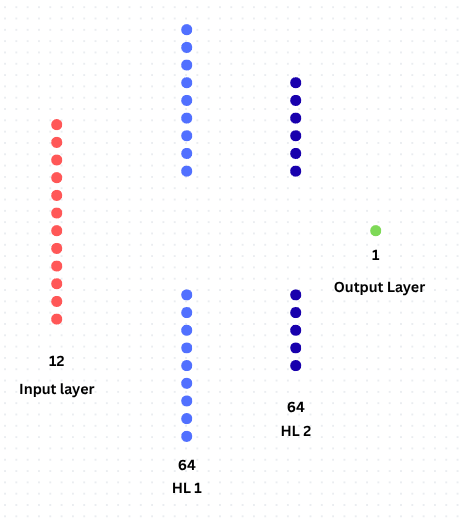

In [28]:
opt=tf.keras.optimizers.Adam(learning_rate=0.01)
loss=tf.keras.losses.BinaryCrossentropy()
loss

<LossFunctionWrapper(<function binary_crossentropy at 0x7b2839fb4b80>, kwargs={'from_logits': False, 'label_smoothing': 0.0, 'axis': -1})>

In [29]:
## compile the model
model.compile(optimizer=opt, loss=loss, metrics=['accuracy'])

In [30]:
## Setup TensorBoard
log_dir="logs/fit"+datetime.datetime.now().strftime("%d%m%Y-%H%M%S")
tensorflow_callback=TensorBoard(log_dir=log_dir, histogram_freq=1)

Setup EarlingStopping : Suppose out epochs is 20, 50 or more like 100. If we reach the global mimima, it much earlier epochs, and no further improvement is achieved like around 6 or 10 epochs then we can stop at the stage only further epochs will not be required

In [31]:
## Setup EarlyStopping
early_stopping_callback=EarlyStopping(monitor='val_loss', 
                                      patience=5,                       # check for 5 epochs is no improvement is observerd
                                      restore_best_weights=True         
                                      )

In [32]:
## Train the model
history=model.fit(
    x_train,
    y_train,
    validation_data=(x_test, y_test),
    epochs=20,
    callbacks=[tensorflow_callback, early_stopping_callback]
)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8317 - loss: 0.3939 - val_accuracy: 0.8595 - val_loss: 0.3562
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8561 - loss: 0.3561 - val_accuracy: 0.8630 - val_loss: 0.3485
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8581 - loss: 0.3476 - val_accuracy: 0.8610 - val_loss: 0.3435
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8606 - loss: 0.3418 - val_accuracy: 0.8605 - val_loss: 0.3437
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8620 - loss: 0.3399 - val_accuracy: 0.8540 - val_loss: 0.3463
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8601 - loss: 0.3389 - val_accuracy: 0.8655 - val_loss: 0.3420
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8616 - loss: 0.3362 - val_accuracy: 0.8620 - val_loss: 0.3472
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8627 - loss: 0.3358 - val_accuracy: 0.

In [34]:
## save the model
model.save('model.h5')

In [35]:
## Load TensorBoard Extension
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [36]:
%reload_ext tensorboard

In [37]:
%tensorboard --logdir logs/fit28052026-121226